# Google Colab File Uploader
This notebook allows you to mount Google Drive and upload files directly to a specific path (either in your Drive or the local Colab environment).

In [1]:
from google.colab import drive
import os

# 1. Mount Google Drive with force_remount to prompt for a new account login
drive.mount('/content/drive')

ModuleNotFoundError: No module named 'google'

In [ ]:
import os

# Check the contents of the upload directory
TARGET_UPLOAD_DIR = '/content/drive/MyDrive/fyp-ml/dataset'

if os.path.exists(TARGET_UPLOAD_DIR):
    uploaded_files = os.listdir(TARGET_UPLOAD_DIR)
    if not uploaded_files:
        print(f"📂 The directory '{TARGET_UPLOAD_DIR}' is empty.")
    else:
        print(f"✅ Found {len(uploaded_files)} file(s) in '{TARGET_UPLOAD_DIR}':\n")
        for i, filename in enumerate(uploaded_files, 1):
            file_path = os.path.join(TARGET_UPLOAD_DIR, filename)
            # Get file size in MB
            size_mb = os.path.getsize(file_path) / (1024 * 1024)
            print(f"{i}. {filename} ({size_mb:.2f} MB)")
else:
    print(f"❌ The directory '{TARGET_UPLOAD_DIR}' does not exist yet.")

✅ Found 4 file(s) in '/content/drive/MyDrive/fyp-ml/dataset':

1. colab_uploader.ipynb (0.01 MB)
2. steps.md (0.01 MB)
3. tikrit_research_data_with_weather.csv (0.00 MB)
4. v2_mixed_11_and_33kv_12million.csv (5516.49 MB)


In [ ]:
import os
import glob
import csv
import subprocess
from io import StringIO
import pandas as pd
from IPython.display import display

# Set to True only if you really need the full dataframe in memory (very heavy for 5.5+ GB)
FULL_LOAD = False

candidate_paths = [
    '/content/drive/MyDrive/fyp-ml/dataset/v2_mixed_11_and_33kv_12million.csv',
    '/content/drive/MyDrive/MySpecificFolder/v2_mixed_11_and_33kv_12million.csv',
    '/content/v2_mixed_11_and_33kv_12million.csv',
]

DATASET_PATH = None
for p in candidate_paths:
    if os.path.exists(p):
        DATASET_PATH = p
        break

if DATASET_PATH is None:
    matches = glob.glob('/content/drive/MyDrive/**/v2_mixed_11_and_33kv_12million.csv', recursive=True)
    if matches:
        DATASET_PATH = matches[0]

if DATASET_PATH is None:
    print('CSV file not found.')
    print('Checked these paths:')
    for p in candidate_paths:
        print(f'- {p}')

    probe_dir = '/content/drive/MyDrive/fyp-ml/dataset'
    print('\nCSV files in probe directory:')
    if os.path.exists(probe_dir):
        csvs = sorted(glob.glob(os.path.join(probe_dir, '*.csv')))
        if csvs:
            for c in csvs:
                size_mb = os.path.getsize(c) / (1024 * 1024)
                print(f'- {os.path.basename(c)} ({size_mb:.2f} MB)')
        else:
            print('- No CSV files found.')
    else:
        print(f'- Missing directory: {probe_dir}')
else:
    size_gb = os.path.getsize(DATASET_PATH) / (1024 ** 3)
    print(f'Found dataset: {DATASET_PATH}')
    print(f'File size: {size_gb:.2f} GB')

    try:
        # Small memory read for the first rows.
        print('Reading first 20 rows...')
        head_df = pd.read_csv(DATASET_PATH, nrows=20)

        # Fast tail read from file end using OS tail to avoid scanning all rows in Python.
        print('Reading last 20 rows...')
        header_line = subprocess.check_output(['head', '-n', '1', DATASET_PATH], text=True)
        tail_text = subprocess.check_output(['tail', '-n', '20', DATASET_PATH], text=True)
        combined = header_line + tail_text

        reader = csv.reader(StringIO(combined))
        rows = list(reader)
        header = rows[0]
        tail_rows = rows[1:]
        tail_df = pd.DataFrame(tail_rows, columns=header)

        print('--- FIRST 20 ROWS ---')
        display(head_df)

        print('\n--- LAST 20 ROWS ---')
        display(tail_df)

        if FULL_LOAD:
            print('\nFULL_LOAD=True: loading full dataset into memory...')
            df = pd.read_csv(DATASET_PATH)
            print(f'Full DataFrame loaded: {df.shape[0]:,} rows x {df.shape[1]} columns')
        else:
            print('\nFULL_LOAD=False: skipped full dataset load to avoid kernel crash.')

    except Exception as e:
        print(f'Failed while reading dataset: {e}')
        print('Tip: Re-run cell 2 (drive mount), then this cell.')

Found dataset: /content/drive/MyDrive/fyp-ml/dataset/v2_mixed_11_and_33kv_12million.csv
File size: 5.39 GB
Reading first 20 rows...
Reading last 20 rows...
--- FIRST 20 ROWS ---


,record_id,simulation_branch,cable_type,voltage_class_kv,voltage_actual_kv,conductor_name,phase_configuration,conductor_height_m,conductor_temp_c,phase_spacing_m,...,precipitation_mm_hr,solar_irradiance_wm2,cloud_cover_pct,dust_density_g_m3,month,hour_of_day,icnirp_e_index,icnirp_b_index,icnirp_exposure_index,quality_flag
0,1ffade8b-eaba-4e6c-856d-a84a1c65931c,B,Overhead Line,33,33.062584,ACSR_Dog,flat,9.879983,16.128117,2.5,...,0.0,0.00000,25.511147,0.023845,11,2,0.013017,0.002749,0.013304,CALCULATED_VERIFIED
1,dfa68626-9975-4bb9-8046-e5c954f62c09,A,Overhead Line,11,10.854926,ACSR_Rabbit,flat,6.399951,40.437458,1.2,...,0.0,900.36300,12.164297,0.063526,10,12,0.001000,0.000200,0.001020,CALCULATED_VERIFIED
2,53bdaafa-624a-4dad-b218-39937c5e290e,U,Underground Cable,33,32.591040,ACSR_Dog,flat,-1.349452,37.270990,2.5,...,0.0,0.00000,15.234894,0.062984,6,23,0.000000,0.003009,0.003009,CALCULATED_VERIFIED
3,c8f8ffeb-59e6-4e95-aada-987fe7c58548,U,Underground Cable,33,33.092422,ACSR_Dog,flat,-1.066065,38.633575,2.5,...,0.0,939.73390,49.197212,0.189970,4,15,0.000000,0.000100,0.000100,CALCULATED_VERIFIED
4,1bc0609f-edd7-423f-979e-423c8203570d,B,Overhead Line,11,10.615051,ACSR_Rabbit,flat,6.000000,58.837060,1.2,...,0.0,1090.62350,0.000000,0.001262,6,9,0.014011,0.008498,0.016386,CALCULATED_VERIFIED
5,afd5cccd-c5d1-4c29-8414-cc1e42980ec3,B,Overhead Line,33,33.686325,ACSR_Dog,flat,9.187959,31.602419,2.5,...,0.0,981.27860,37.205300,0.032998,4,9,0.006889,0.001630,0.007080,CALCULATED_VERIFIED
6,00a731d0-9c09-4f01-adb8-0841bf9eaf8d,B,Overhead Line,11,11.186819,ACSR_Rabbit,flat,7.344115,15.431524,1.2,...,0.0,0.00000,54.798330,0.043554,3,4,0.013983,0.004903,0.014817,CALCULATED_VERIFIED
7,ea4a8d46-607d-4812-ab64-45727095e86b,B,Overhead Line,33,31.812614,ACSR_Dog,flat,9.632798,23.675470,2.5,...,0.0,943.05930,47.985672,0.006797,2,13,0.029904,0.005045,0.030326,CALCULATED_VERIFIED
8,adc2db15-5d76-4f8e-8fe1-7d5f181850c6,A,Overhead Line,11,11.094061,ACSR_Rabbit,flat,6.599254,34.702587,1.2,...,0.0,418.27133,18.647520,0.036144,4,17,0.001000,0.000771,0.001263,CALCULATED_VERIFIED
9,0d81fa2f-bba5-4d0f-99d7-c588a525fb70,A,Overhead Line,11,10.690276,ACSR_Rabbit,flat,6.892129,27.651756,1.2,...,0.0,552.62805,38.142258,0.008824,11,14,0.002430,0.000133,0.002434,CALCULATED_VERIFIED



--- LAST 20 ROWS ---


,record_id,simulation_branch,cable_type,voltage_class_kv,voltage_actual_kv,conductor_name,phase_configuration,conductor_height_m,conductor_temp_c,phase_spacing_m,...,precipitation_mm_hr,solar_irradiance_wm2,cloud_cover_pct,dust_density_g_m3,month,hour_of_day,icnirp_e_index,icnirp_b_index,icnirp_exposure_index,quality_flag
0,67e0b8c4-8317-48c5-a453-a13908567b36,A,Overhead Line,11,11.51436,ACSR_Rabbit,flat,7.3442826,17.79359,1.2,...,0.0,0.0,34.40336,0.028906398,3,1,0.00548796,0.0019528441,0.005825058,CALCULATED_VERIFIED
1,14ddd99f-2542-4ef9-9132-854bd7494a8d,B,Overhead Line,33,34.447823,ACSR_Dog,flat,9.498871,25.886524,2.5,...,0.0,0.0,43.544662,0.10915652,4,20,0.0120331915,0.0022537173,0.012242424,CALCULATED_VERIFIED
2,db0f5793-014d-4df9-b9ae-8f47188ed3ec,B,Overhead Line,33,31.84156,ACSR_Dog,flat,7.988039,61.398518,2.5,...,0.0,1269.3076,35.910637,0.062047966,6,14,0.036018454,0.013077784,0.03831915,CALCULATED_VERIFIED
3,29e5263d-174d-4454-a857-b1a4daf73130,B,Overhead Line,11,10.763602,ACSR_Rabbit,flat,7.344284,16.265387,1.2,...,0.0,0.0,44.668964,0.025321145,12,19,0.012116759,0.0034244964,0.012591386,CALCULATED_VERIFIED
4,72c2cef5-6efa-4959-af41-d655a86095fa,A,Overhead Line,11,11.23743,ACSR_Rabbit,flat,6.579177,35.246185,1.2,...,0.0,509.10974,29.481913,0.024698023,10,9,0.009639396,0.0026393174,0.009994196,CALCULATED_VERIFIED
5,493d062a-f8ae-4a41-a196-2cccc43fae4b,B,Overhead Line,33,34.17694,ACSR_Dog,flat,8.729935,41.527557,2.5,...,0.0,0.0,30.067402,0.028723996,8,1,0.005221071,0.0020863826,0.005622506,CALCULATED_VERIFIED
6,afa5bdfa-aa8a-4db3-8fe0-311e83088178,A,Overhead Line,11,10.8201065,ACSR_Rabbit,flat,6.350193,41.989777,1.2,...,0.0,0.0,37.358868,0.033707015,5,19,0.005771785,0.0023732074,0.0062406426,CALCULATED_VERIFIED
7,1dee7297-dc38-4659-9653-8452ff5989d7,U,Underground Cable,33,31.764685,ACSR_Dog,flat,-1.4741483,40.20084,2.5,...,0.0,0.0,36.2011,0.017899223,5,19,0.0,0.0041937535,0.0041937535,CALCULATED_VERIFIED
8,c15d4777-11d6-4e05-9b4f-7c60f9541951,U,Underground Cable,11,11.221512,ACSR_Rabbit,flat,-1.0242308,16.932705,1.2,...,0.0,0.0,27.187294,0.056718677,11,0,0.0,0.0013150461,0.0013150461,CALCULATED_VERIFIED
9,a3d89af0-f21c-4066-bfc1-9ca2dab240b8,A,Overhead Line,11,10.5022955,ACSR_Rabbit,flat,6.6262293,33.980843,1.2,...,0.0,0.0,41.707996,0.066545665,9,4,0.0009999999,0.0008979933,0.0013440207,CALCULATED_VERIFIED



FULL_LOAD=False: skipped full dataset load to avoid kernel crash.


In [ ]:
# Deep crash diagnostics: run this before heavy cells if kernel becomes unstable.
import os
import subprocess
import pandas as pd

DATASET_PATH = '/content/drive/MyDrive/fyp-ml/dataset/v2_mixed_11_and_33kv_12million.csv'

print('=== Kernel / System Diagnostics ===')
print('Python version:')
print(subprocess.check_output(['python3', '--version'], text=True).strip())

print('\nMemory snapshot (MB):')
print(subprocess.check_output(['bash', '-lc', "free -m | sed -n '1,2p'"], text=True))

print('Drive mounted?')
print('YES' if os.path.exists('/content/drive/MyDrive') else 'NO')

print(f'\nDataset exists at expected path? {os.path.exists(DATASET_PATH)}')
if os.path.exists(DATASET_PATH):
    size_gb = os.path.getsize(DATASET_PATH) / (1024 ** 3)
    print(f'Dataset size: {size_gb:.2f} GB')

    print('\nQuick parse test (first 5 rows) ...')
    try:
        test_df = pd.read_csv(DATASET_PATH, nrows=5)
        print('OK: parser can read dataset header and first rows.')
        print(f'Columns: {list(test_df.columns)}')
    except Exception as e:
        print(f'Parser test failed: {e}')
else:
    print('Dataset is missing at expected path. Use the upload/check cells first.')

=== Kernel / System Diagnostics ===
Python version:
Python 3.12.12

Memory snapshot (MB):
               total        used        free      shared  buff/cache   available
Mem:           12975         794       11314           2         867       11880

Drive mounted?
YES

Dataset exists at expected path? True
Dataset size: 5.39 GB

Quick parse test (first 5 rows) ...
OK: parser can read dataset header and first rows.
Columns: ['record_id', 'simulation_branch', 'cable_type', 'voltage_class_kv', 'voltage_actual_kv', 'conductor_name', 'phase_configuration', 'conductor_height_m', 'conductor_temp_c', 'phase_spacing_m', 'span_length_m', 'line_current_A', 'load_factor', 'power_factor', 'thd_current_pct', 'frequency_hz', 'lateral_distance_m', 'measurement_height_m', 'ground_conductivity_S_m', 'e_field_kv_m', 'e_field_calculated_kv_m', 'e_field_vacuum_kv_m', 'e_field_x_kv_m', 'e_field_y_kv_m', 'atmospheric_eps_r', 'e_above_noise_floor', 'b_field_uT', 'b_field_calculated_uT', 'b_field_max_ellips

Using dataset: /content/drive/MyDrive/fyp-ml/dataset/v2_mixed_11_and_33kv_12million.csv
Sampled rows for plotting: 220,000
Columns used: ['cable_type', 'voltage_class_kv', 'voltage_actual_kv', 'line_current_A', 'lateral_distance_m', 'b_field_uT', 'temperature_c', 'relative_humidity_pct']


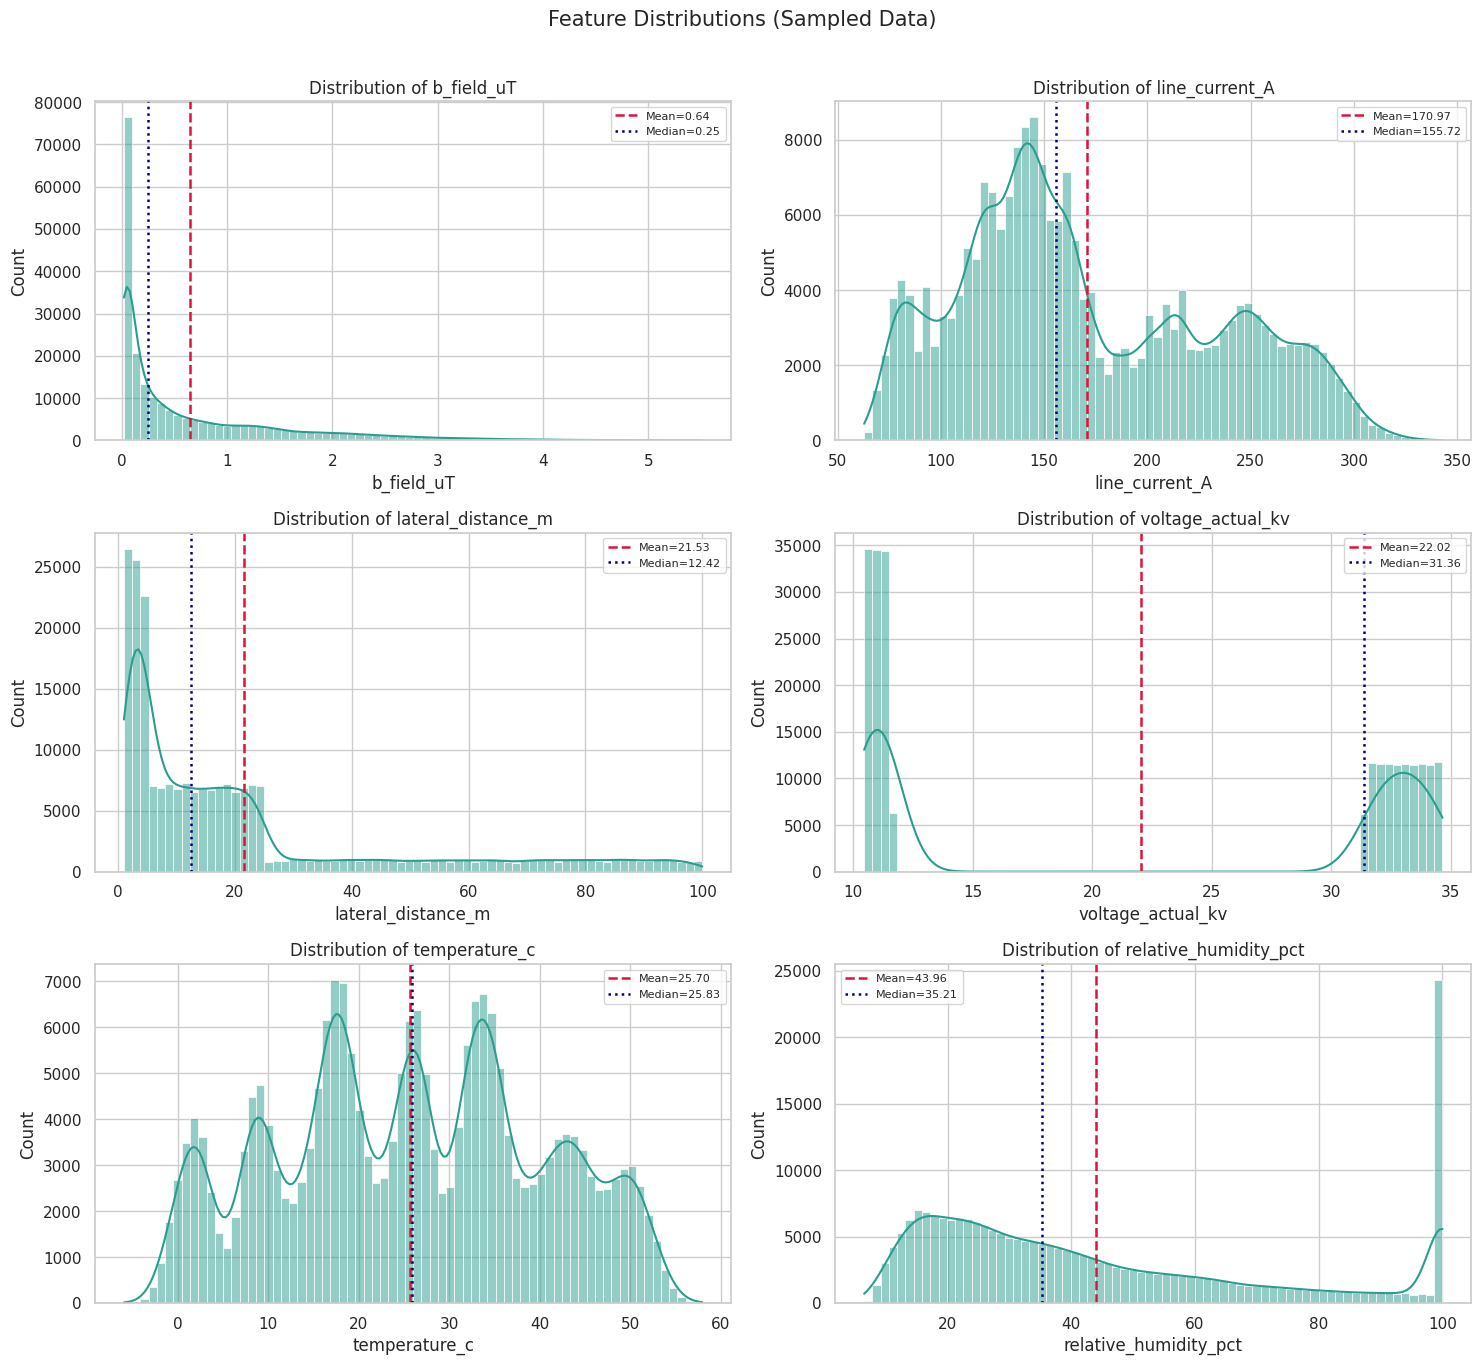

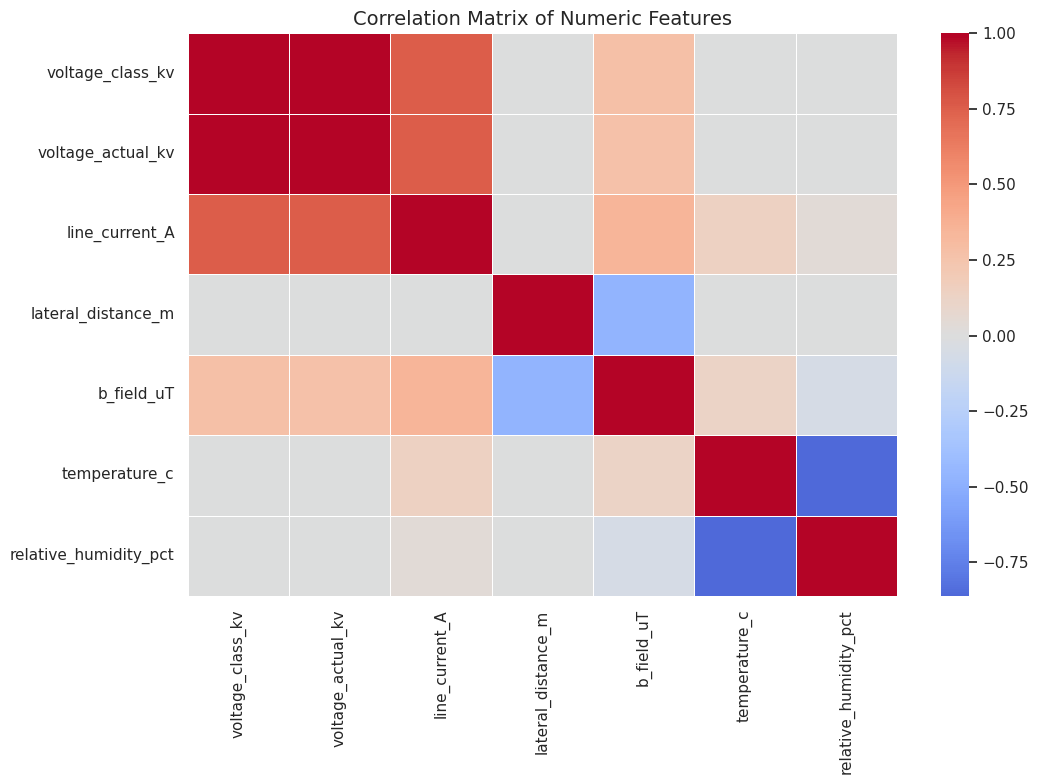

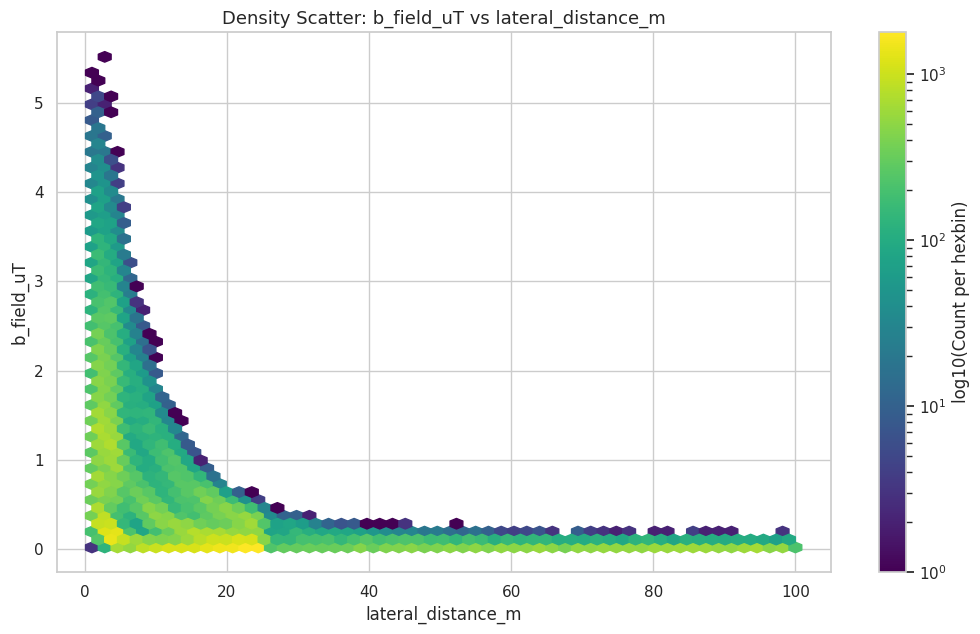

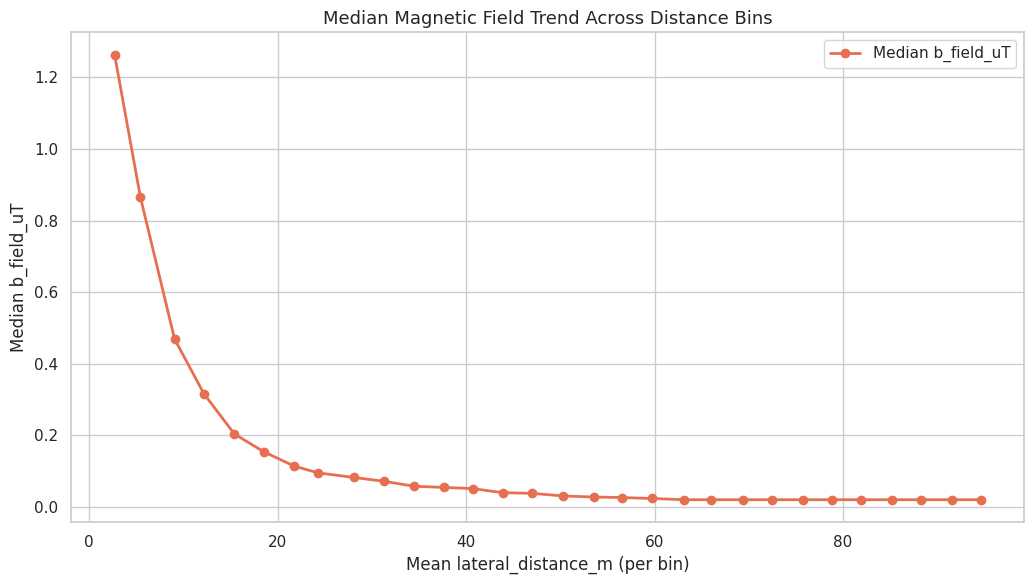

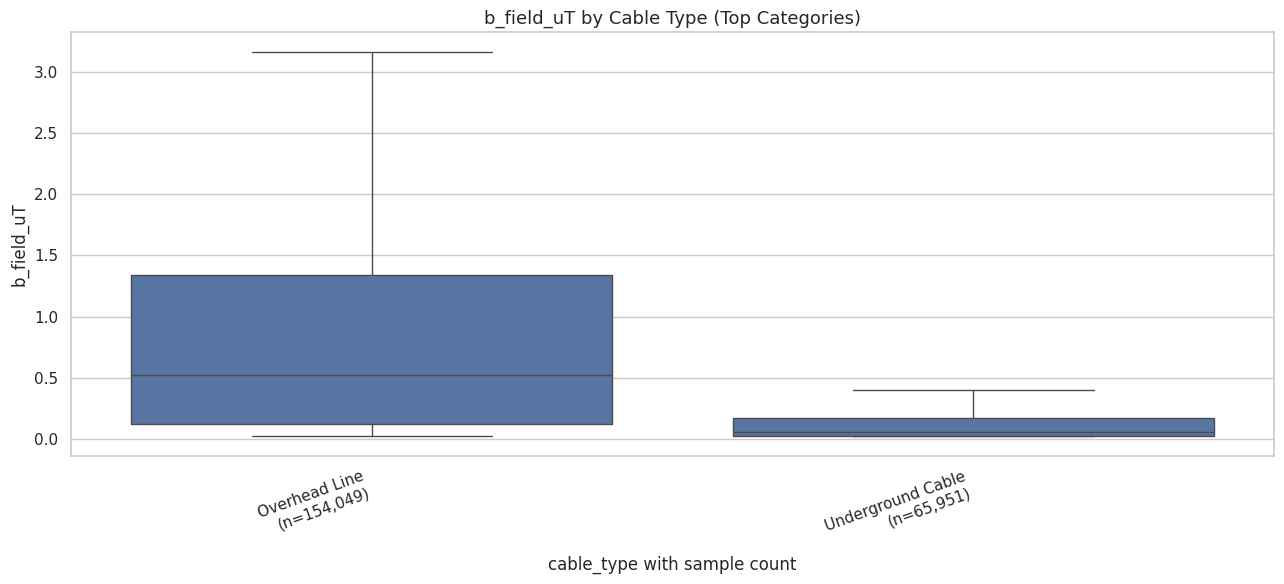

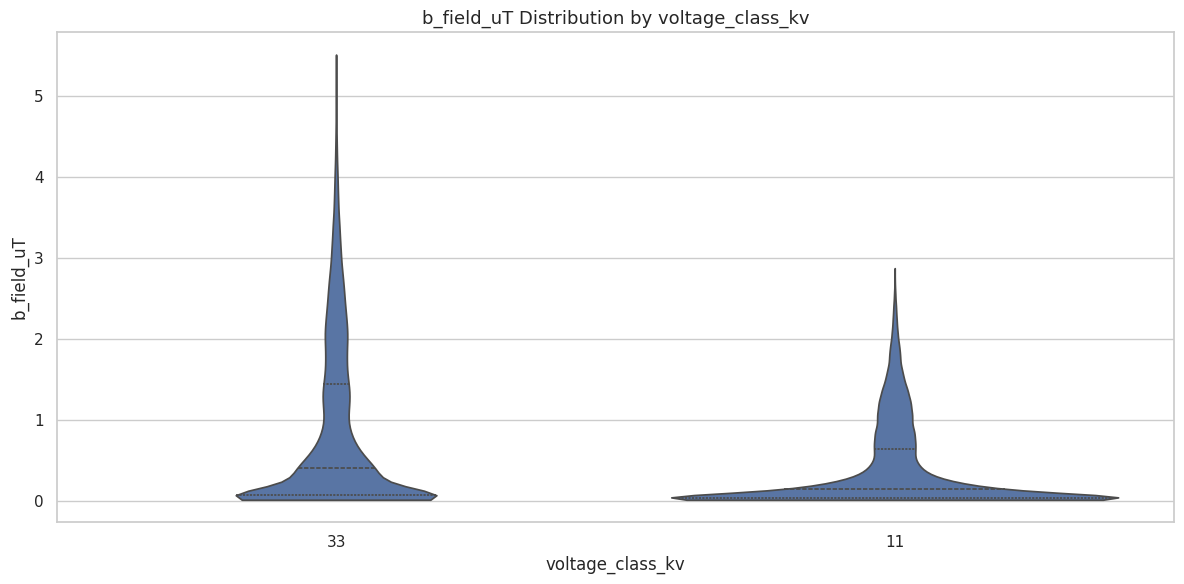


Summary stats for b_field_uT (sampled):
count    220000.000000
mean          0.643587
std           0.839136
min           0.020000
10%           0.020000
25%           0.051155
50%           0.252505
75%           0.964994
90%           1.907741
max           5.512569


In [ ]:
# Advanced distribution + labeled plots (memory-safe for very large CSV)
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    import seaborn as sns
    has_seaborn = True
except Exception:
    has_seaborn = False

if has_seaborn:
    sns.set_theme(style='whitegrid', context='notebook')

# Resolve dataset path safely
candidate_paths = [
    '/content/drive/MyDrive/fyp-ml/dataset/v2_mixed_11_and_33kv_12million.csv',
    '/content/drive/MyDrive/MySpecificFolder/v2_mixed_11_and_33kv_12million.csv',
    '/content/v2_mixed_11_and_33kv_12million.csv',
]

dataset_path = None
if 'DATASET_PATH' in globals() and isinstance(DATASET_PATH, str) and os.path.exists(DATASET_PATH):
    dataset_path = DATASET_PATH
else:
    for p in candidate_paths:
        if os.path.exists(p):
            dataset_path = p
            break

if dataset_path is None:
    matches = glob.glob('/content/drive/MyDrive/**/v2_mixed_11_and_33kv_12million.csv', recursive=True)
    if matches:
        dataset_path = matches[0]

if dataset_path is None:
    print('Dataset not found. Run mount/check cells first.')
else:
    print(f'Using dataset: {dataset_path}')

    # Selected columns for advanced EDA
    preferred_cols = [
        'b_field_uT',
        'line_current_A',
        'lateral_distance_m',
        'voltage_actual_kv',
        'temperature_c',
        'relative_humidity_pct',
        'voltage_class_kv',
        'cable_type',
    ]

    available_cols = list(pd.read_csv(dataset_path, nrows=0).columns)
    usecols = [c for c in preferred_cols if c in available_cols]

    if len(usecols) < 3:
        print('Not enough expected columns found for plotting.')
        print('Available columns (first 25):', available_cols[:25])
    else:
        # Chunk sampling to avoid loading all rows
        target_rows = 220000
        per_chunk_take = 9000
        chunksize = 250000
        sampled_parts = []

        for i, chunk in enumerate(pd.read_csv(dataset_path, usecols=usecols, chunksize=chunksize)):
            chunk = chunk.dropna(how='any')
            if len(chunk) == 0:
                continue
            n_take = min(per_chunk_take, len(chunk))
            sampled_parts.append(chunk.sample(n=n_take, random_state=100 + i))
            if sum(len(x) for x in sampled_parts) >= target_rows:
                break

        if not sampled_parts:
            print('Sampling failed: no rows available after cleaning.')
        else:
            plot_df = pd.concat(sampled_parts, ignore_index=True)
            if len(plot_df) > target_rows:
                plot_df = plot_df.sample(n=target_rows, random_state=123)

            print(f'Sampled rows for plotting: {len(plot_df):,}')
            print('Columns used:', list(plot_df.columns))

            numeric_cols = plot_df.select_dtypes(include=[np.number]).columns.tolist()
            has_b = 'b_field_uT' in plot_df.columns
            has_dist = 'lateral_distance_m' in plot_df.columns
            has_current = 'line_current_A' in plot_df.columns
            has_cable = 'cable_type' in plot_df.columns
            has_vclass = 'voltage_class_kv' in plot_df.columns

            # -----------------------------------------------------------------
            # Plot 1: Advanced distributions with mean/median labels
            # -----------------------------------------------------------------
            dist_cols = [c for c in ['b_field_uT', 'line_current_A', 'lateral_distance_m', 'voltage_actual_kv', 'temperature_c', 'relative_humidity_pct'] if c in numeric_cols]
            if dist_cols:
                ncols = 2
                nrows = int(np.ceil(len(dist_cols) / ncols))
                fig, axes = plt.subplots(nrows, ncols, figsize=(15, 4.5 * nrows))
                axes = np.array(axes).reshape(-1)

                for idx, col in enumerate(dist_cols):
                    ax = axes[idx]
                    series = pd.to_numeric(plot_df[col], errors='coerce').dropna()
                    if has_seaborn:
                        sns.histplot(series, bins=70, kde=True, ax=ax, color='#2a9d8f', edgecolor=None)
                    else:
                        ax.hist(series, bins=70, color='#2a9d8f', alpha=0.85)

                    mean_v = series.mean()
                    med_v = series.median()
                    ax.axvline(mean_v, color='crimson', linestyle='--', linewidth=1.8, label=f'Mean={mean_v:.2f}')
                    ax.axvline(med_v, color='navy', linestyle=':', linewidth=1.8, label=f'Median={med_v:.2f}')
                    ax.set_title(f'Distribution of {col}', fontsize=12)
                    ax.set_xlabel(col)
                    ax.set_ylabel('Count')
                    ax.legend(loc='best', fontsize=8)

                for j in range(len(dist_cols), len(axes)):
                    axes[j].axis('off')

                plt.suptitle('Feature Distributions (Sampled Data)', fontsize=15, y=1.01)
                plt.tight_layout()
                plt.show()

            # -----------------------------------------------------------------
            # Plot 2: Correlation heatmap with labels
            # -----------------------------------------------------------------
            if len(numeric_cols) >= 3:
                corr = plot_df[numeric_cols].corr(numeric_only=True)
                plt.figure(figsize=(11, 8))
                if has_seaborn:
                    sns.heatmap(corr, cmap='coolwarm', center=0, annot=False, linewidths=0.4)
                else:
                    plt.imshow(corr, cmap='coolwarm', aspect='auto')
                    plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
                    plt.yticks(range(len(corr.columns)), corr.columns)
                    plt.colorbar(label='Correlation')
                plt.title('Correlation Matrix of Numeric Features', fontsize=14)
                plt.tight_layout()
                plt.show()

            # -----------------------------------------------------------------
            # Plot 3: Hexbin scatter (distance vs B-field) with colorbar label
            # -----------------------------------------------------------------
            if has_b and has_dist:
                plt.figure(figsize=(10.5, 6.5))
                hb_df = plot_df[['lateral_distance_m', 'b_field_uT']].dropna().sample(
                    n=min(120000, len(plot_df)), random_state=7
                )
                hb = plt.hexbin(
                    hb_df['lateral_distance_m'],
                    hb_df['b_field_uT'],
                    gridsize=55,
                    cmap='viridis',
                    mincnt=1,
                    bins='log'
                )
                cb = plt.colorbar(hb)
                cb.set_label('log10(Count per hexbin)')
                plt.title('Density Scatter: b_field_uT vs lateral_distance_m', fontsize=13)
                plt.xlabel('lateral_distance_m')
                plt.ylabel('b_field_uT')
                plt.tight_layout()
                plt.show()

            # -----------------------------------------------------------------
            # Plot 4: Trend line of median B-field by distance bins
            # -----------------------------------------------------------------
            if has_b and has_dist:
                temp = plot_df[['lateral_distance_m', 'b_field_uT']].dropna().copy()
                q_low = temp['lateral_distance_m'].quantile(0.01)
                q_hi = temp['lateral_distance_m'].quantile(0.99)
                temp = temp[(temp['lateral_distance_m'] >= q_low) & (temp['lateral_distance_m'] <= q_hi)]
                temp['distance_bin'] = pd.cut(temp['lateral_distance_m'], bins=30)
                agg = temp.groupby('distance_bin', observed=False).agg(
                    median_b=('b_field_uT', 'median'),
                    mean_dist=('lateral_distance_m', 'mean'),
                    n=('b_field_uT', 'size')
                ).dropna()

                plt.figure(figsize=(10.5, 6))
                plt.plot(agg['mean_dist'], agg['median_b'], marker='o', linewidth=2, color='#e76f51', label='Median b_field_uT')
                plt.title('Median Magnetic Field Trend Across Distance Bins', fontsize=13)
                plt.xlabel('Mean lateral_distance_m (per bin)')
                plt.ylabel('Median b_field_uT')
                plt.legend()
                plt.tight_layout()
                plt.show()

            # -----------------------------------------------------------------
            # Plot 5: Boxplot with labeled categories and counts
            # -----------------------------------------------------------------
            if has_b and has_cable:
                tmp = plot_df[['cable_type', 'b_field_uT']].dropna().copy()
                top_counts = tmp['cable_type'].astype(str).value_counts().head(8)
                keep = top_counts.index.tolist()
                box_df = tmp[tmp['cable_type'].astype(str).isin(keep)].copy()

                label_map = {k: f"{k}\n(n={int(v):,})" for k, v in top_counts.items()}
                box_df['cable_label'] = box_df['cable_type'].astype(str).map(label_map)

                plt.figure(figsize=(13, 6))
                if has_seaborn:
                    sns.boxplot(data=box_df, x='cable_label', y='b_field_uT', showfliers=False)
                else:
                    order = [label_map[k] for k in keep]
                    groups = [box_df.loc[box_df['cable_label'] == lbl, 'b_field_uT'].values for lbl in order]
                    plt.boxplot(groups, labels=order, showfliers=False)
                plt.title('b_field_uT by Cable Type (Top Categories)', fontsize=13)
                plt.xlabel('cable_type with sample count')
                plt.ylabel('b_field_uT')
                plt.xticks(rotation=20, ha='right')
                plt.tight_layout()
                plt.show()

            # -----------------------------------------------------------------
            # Plot 6: Violin/box by voltage class (if available)
            # -----------------------------------------------------------------
            if has_b and has_vclass:
                vv = plot_df[['voltage_class_kv', 'b_field_uT']].dropna().copy()
                vv['voltage_class_kv'] = vv['voltage_class_kv'].astype(str)
                top_v = vv['voltage_class_kv'].value_counts().head(8).index.tolist()
                vv = vv[vv['voltage_class_kv'].isin(top_v)]

                plt.figure(figsize=(12, 6))
                if has_seaborn:
                    sns.violinplot(data=vv, x='voltage_class_kv', y='b_field_uT', inner='quartile', cut=0)
                else:
                    groups = [vv.loc[vv['voltage_class_kv'] == t, 'b_field_uT'].values for t in top_v]
                    plt.boxplot(groups, labels=top_v, showfliers=False)
                plt.title('b_field_uT Distribution by voltage_class_kv', fontsize=13)
                plt.xlabel('voltage_class_kv')
                plt.ylabel('b_field_uT')
                plt.tight_layout()
                plt.show()

            # Optional summary table for quick interpretation
            if has_b:
                print('\nSummary stats for b_field_uT (sampled):')
                print(plot_df['b_field_uT'].describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9]).to_string())

Using dataset: /content/drive/MyDrive/fyp-ml/dataset/v2_mixed_11_and_33kv_12million.csv

Line class distribution in sample:
line_class
Overhead       153802
Underground     66198


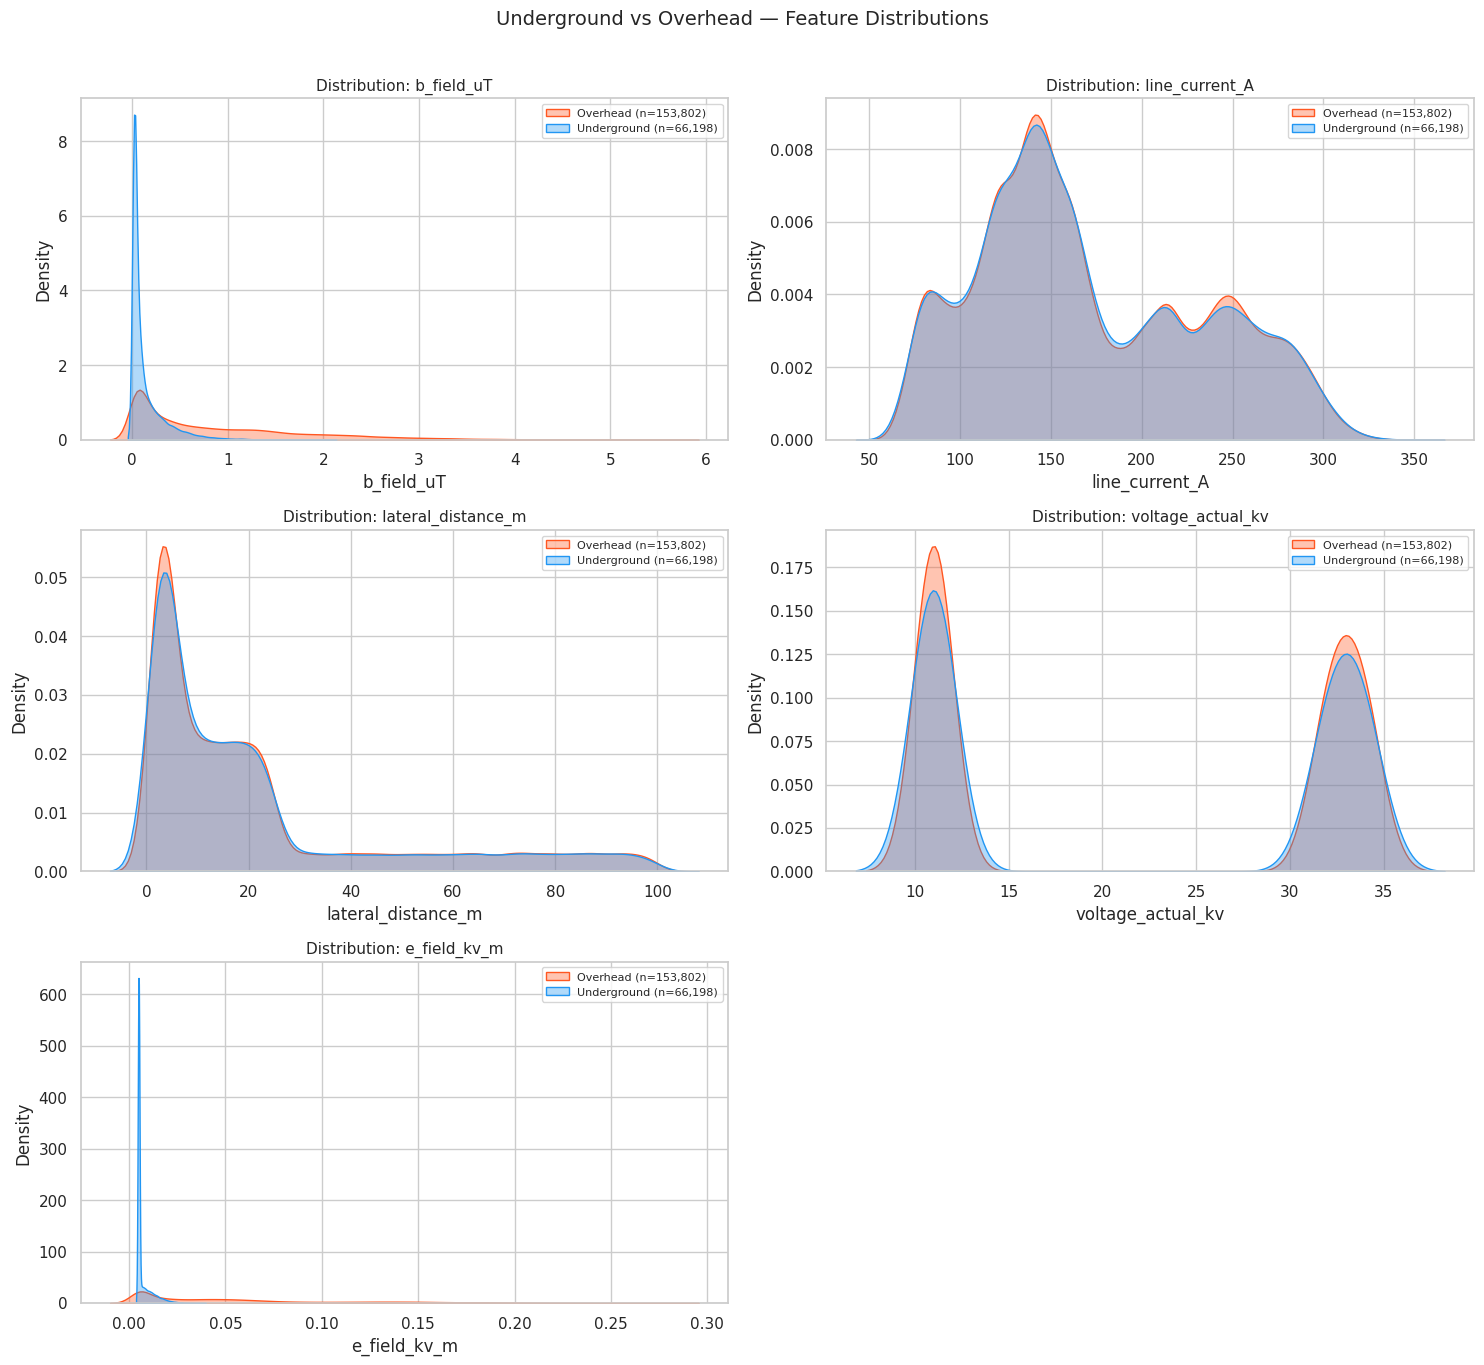

/tmp/ipykernel_12807/391529486.py:130: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(grp_data, labels=main_classes, patch_artist=True, showfliers=False, notch=True)
/tmp/ipykernel_12807/391529486.py:130: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(grp_data, labels=main_classes, patch_artist=True, showfliers=False, notch=True)
/tmp/ipykernel_12807/391529486.py:130: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(grp_data, labels=main_classes, patch_artist=True, showfliers=False, notch=True)
/tmp/ipykernel_12807/391529486.py:130: MatplotlibDeprecationWarning: The 'labels' 

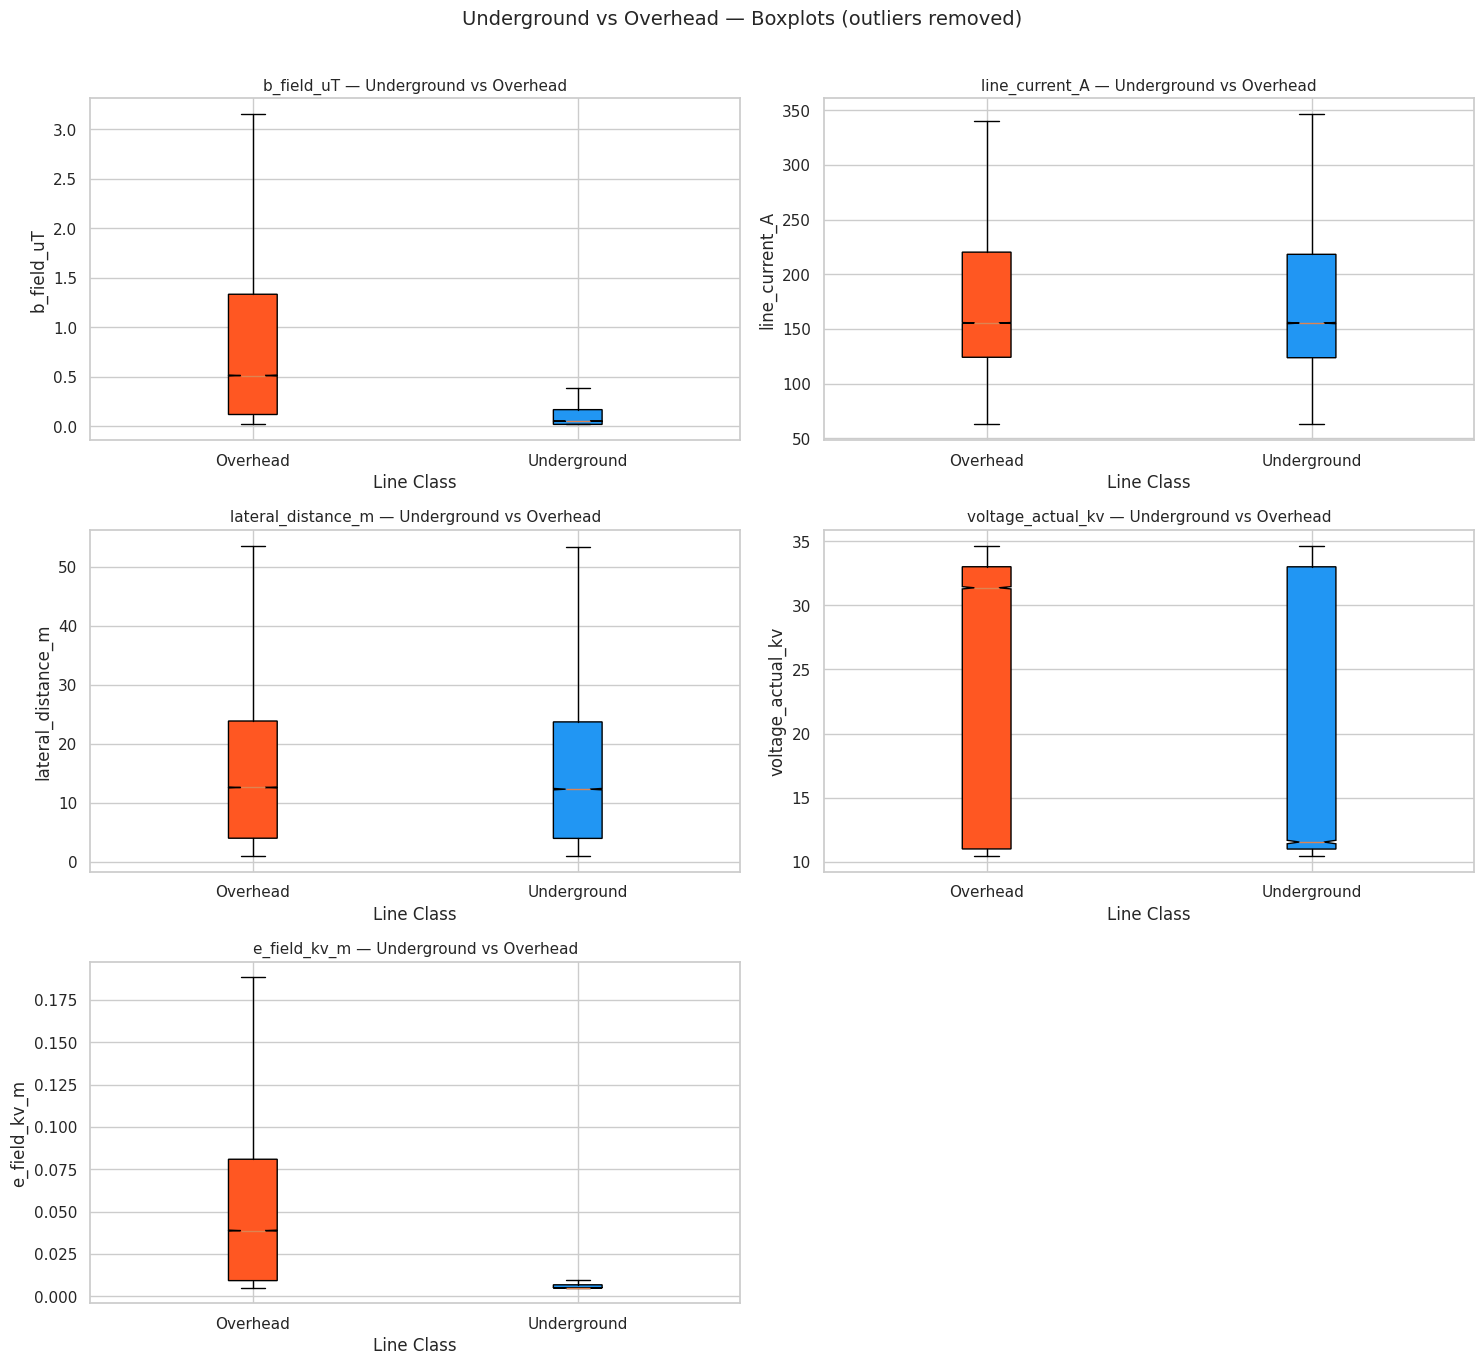

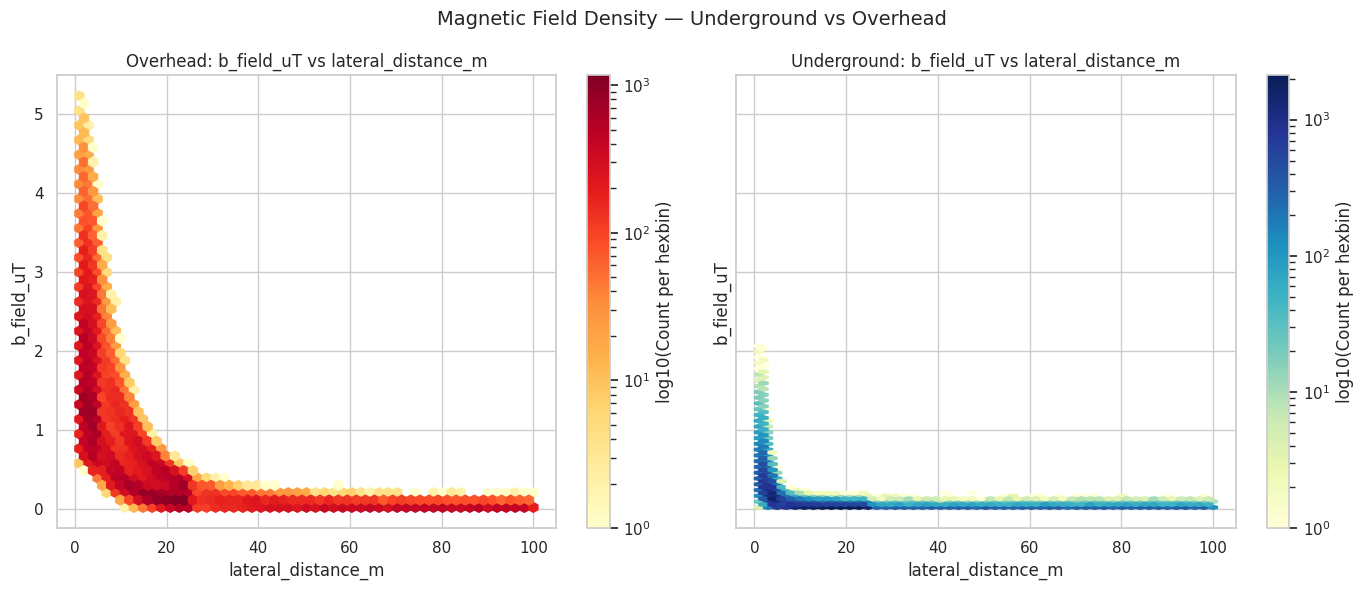

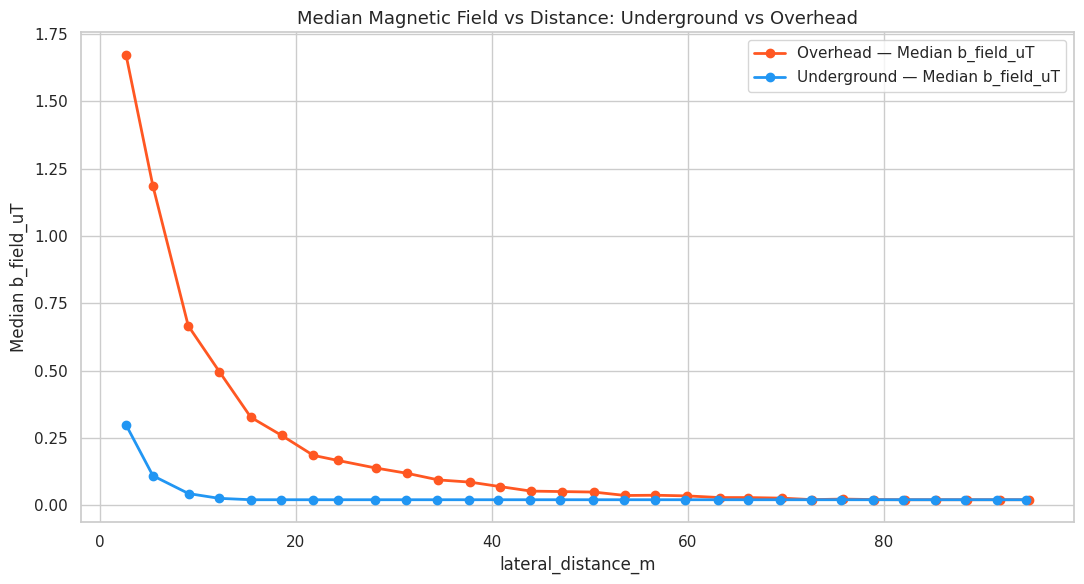


=== Statistical Summary: Underground vs Overhead ===

  Feature: b_field_uT
    Overhead     | mean=    0.854  median=    0.513  std=    0.912  min=    0.020  max=    5.673
    Underground  | mean=    0.139  median=    0.052  std=    0.201  min=    0.020  max=    2.069

  Feature: line_current_A
    Overhead     | mean=  170.866  median=  155.471  std=   61.690  min=   62.781  max=  340.092
    Underground  | mean=  170.422  median=  155.361  std=   61.652  min=   62.804  max=  346.566

  Feature: lateral_distance_m
    Overhead     | mean=   21.720  median=   12.611  std=   25.124  min=    1.000  max=   99.984
    Underground  | mean=   21.438  median=   12.326  std=   24.950  min=    1.000  max=   99.984

  Feature: voltage_actual_kv
    Overhead     | mean=   22.024  median=   31.356  std=   11.022  min=   10.450  max=   34.650
    Underground  | mean=   21.932  median=   11.542  std=   11.022  min=   10.450  max=   34.650

  Feature: e_field_kv_m
    Overhead     | mean=    0.055 

In [ ]:
# Underground vs Overhead Comparative Analysis (memory-safe)
import os, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

try:
    import seaborn as sns
    has_seaborn = True
    sns.set_theme(style='whitegrid', context='notebook')
except Exception:
    has_seaborn = False

# Resolve path
dataset_path = None
if 'DATASET_PATH' in globals() and isinstance(DATASET_PATH, str) and os.path.exists(DATASET_PATH):
    dataset_path = DATASET_PATH
else:
    for p in [
        '/content/drive/MyDrive/fyp-ml/dataset/v2_mixed_11_and_33kv_12million.csv',
        '/content/drive/MyDrive/MySpecificFolder/v2_mixed_11_and_33kv_12million.csv',
        '/content/v2_mixed_11_and_33kv_12million.csv',
    ]:
        if os.path.exists(p):
            dataset_path = p
            break

if dataset_path is None:
    matches = glob.glob('/content/drive/MyDrive/**/v2_mixed_11_and_33kv_12million.csv', recursive=True)
    if matches:
        dataset_path = matches[0]

if dataset_path is None:
    print('Dataset not found. Run mount/check cells first.')
else:
    print(f'Using dataset: {dataset_path}')

    COMPARE_COLS = [
        'cable_type',
        'b_field_uT',
        'line_current_A',
        'lateral_distance_m',
        'voltage_actual_kv',
        'temperature_c',
        'e_field_kv_m',
    ]
    available_cols = list(pd.read_csv(dataset_path, nrows=0).columns)
    usecols = [c for c in COMPARE_COLS if c in available_cols]

    if 'cable_type' not in usecols:
        print("'cable_type' column not found. Available columns:", available_cols[:30])
    else:
        # Chunk sample
        sampled_parts = []
        target_rows = 220000
        for i, chunk in enumerate(pd.read_csv(dataset_path, usecols=usecols, chunksize=250000)):
            chunk = chunk.dropna(how='any')
            if len(chunk):
                sampled_parts.append(chunk.sample(n=min(9000, len(chunk)), random_state=200 + i))
            if sum(len(x) for x in sampled_parts) >= target_rows:
                break

        df = pd.concat(sampled_parts, ignore_index=True)
        if len(df) > target_rows:
            df = df.sample(n=target_rows, random_state=99)

        # Classify each row as Underground or Overhead
        df['line_class'] = df['cable_type'].astype(str).apply(
            lambda x: 'Underground' if 'underground' in x.lower() or 'ug' in x.lower() or 'cable' in x.lower()
            else ('Overhead' if 'overhead' in x.lower() or 'oh' in x.lower() or 'line' in x.lower()
                  else 'Other')
        )

        counts = df['line_class'].value_counts()
        print('\nLine class distribution in sample:')
        print(counts.to_string())

        main_classes = counts[counts >= 200].index.tolist()
        if not main_classes:
            print('\nNo underground/overhead labels detected.')
            print('Unique cable_type values (first 15):', df['cable_type'].unique()[:15].tolist())
        else:
            df_main = df[df['line_class'].isin(main_classes)].copy()
            PALETTE = {'Underground': '#2196F3', 'Overhead': '#FF5722', 'Other': '#9E9E9E'}

            numeric_compare = [c for c in ['b_field_uT', 'line_current_A', 'lateral_distance_m', 'voltage_actual_kv', 'e_field_kv_m'] if c in df_main.columns]

            # ----------------------------------------------------------------
            # Plot 1: Distribution overlay — Overhead vs Underground per feature
            # ----------------------------------------------------------------
            ncols = 2
            nrows = int(np.ceil(len(numeric_compare) / ncols))
            fig, axes = plt.subplots(nrows, ncols, figsize=(15, 4.5 * nrows))
            axes = np.array(axes).reshape(-1)

            for idx, col in enumerate(numeric_compare):
                ax = axes[idx]
                for lc in main_classes:
                    grp = pd.to_numeric(df_main.loc[df_main['line_class'] == lc, col], errors='coerce').dropna()
                    color = PALETTE.get(lc, '#888888')
                    if has_seaborn:
                        sns.kdeplot(grp, ax=ax, label=f'{lc} (n={len(grp):,})', fill=True, alpha=0.35, color=color)
                    else:
                        ax.hist(grp, bins=60, alpha=0.5, label=f'{lc} (n={len(grp):,})', color=color, density=True)

                ax.set_title(f'Distribution: {col}', fontsize=11)
                ax.set_xlabel(col)
                ax.set_ylabel('Density')
                ax.legend(fontsize=8)

            for j in range(len(numeric_compare), len(axes)):
                axes[j].axis('off')

            plt.suptitle('Underground vs Overhead — Feature Distributions', fontsize=14, y=1.01)
            plt.tight_layout()
            plt.show()

            # ----------------------------------------------------------------
            # Plot 2: Side-by-side boxplot for each numeric feature
            # ----------------------------------------------------------------
            ncols = 2
            nrows = int(np.ceil(len(numeric_compare) / ncols))
            fig, axes = plt.subplots(nrows, ncols, figsize=(15, 4.5 * nrows))
            axes = np.array(axes).reshape(-1)

            for idx, col in enumerate(numeric_compare):
                ax = axes[idx]
                grp_data = [df_main.loc[df_main['line_class'] == lc, col].dropna().values for lc in main_classes]
                bp = ax.boxplot(grp_data, labels=main_classes, patch_artist=True, showfliers=False, notch=True)
                for patch, lc in zip(bp['boxes'], main_classes):
                    patch.set_facecolor(PALETTE.get(lc, '#aaa'))
                ax.set_title(f'{col} — Underground vs Overhead', fontsize=11)
                ax.set_xlabel('Line Class')
                ax.set_ylabel(col)

            for j in range(len(numeric_compare), len(axes)):
                axes[j].axis('off')

            plt.suptitle('Underground vs Overhead — Boxplots (outliers removed)', fontsize=14, y=1.01)
            plt.tight_layout()
            plt.show()

            # ----------------------------------------------------------------
            # Plot 3: B-field vs Distance — colored by line class (hexbin per class)
            # ----------------------------------------------------------------
            if 'b_field_uT' in df_main.columns and 'lateral_distance_m' in df_main.columns:
                fig, axes = plt.subplots(1, len(main_classes), figsize=(7 * len(main_classes), 6), sharey=True)
                if len(main_classes) == 1:
                    axes = [axes]
                for ax, lc in zip(axes, main_classes):
                    sub = df_main[df_main['line_class'] == lc][['lateral_distance_m', 'b_field_uT']].dropna()
                    sub = sub.sample(n=min(80000, len(sub)), random_state=5)
                    hb = ax.hexbin(sub['lateral_distance_m'], sub['b_field_uT'],
                                   gridsize=50, cmap='YlOrRd' if lc == 'Overhead' else 'YlGnBu',
                                   mincnt=1, bins='log')
                    plt.colorbar(hb, ax=ax, label='log10(Count per hexbin)')
                    ax.set_title(f'{lc}: b_field_uT vs lateral_distance_m', fontsize=12)
                    ax.set_xlabel('lateral_distance_m')
                    ax.set_ylabel('b_field_uT')

                plt.suptitle('Magnetic Field Density — Underground vs Overhead', fontsize=14)
                plt.tight_layout()
                plt.show()

            # ----------------------------------------------------------------
            # Plot 4: Median B-field trend by distance bin — both classes overlaid
            # ----------------------------------------------------------------
            if 'b_field_uT' in df_main.columns and 'lateral_distance_m' in df_main.columns:
                plt.figure(figsize=(11, 6))
                for lc in main_classes:
                    sub = df_main[df_main['line_class'] == lc][['lateral_distance_m', 'b_field_uT']].dropna()
                    q_lo = sub['lateral_distance_m'].quantile(0.01)
                    q_hi = sub['lateral_distance_m'].quantile(0.99)
                    sub = sub[(sub['lateral_distance_m'] >= q_lo) & (sub['lateral_distance_m'] <= q_hi)]
                    sub['dist_bin'] = pd.cut(sub['lateral_distance_m'], bins=30)
                    agg = sub.groupby('dist_bin', observed=False).agg(
                        med=('b_field_uT', 'median'),
                        mean_dist=('lateral_distance_m', 'mean')
                    ).dropna()
                    color = PALETTE.get(lc, '#888')
                    plt.plot(agg['mean_dist'], agg['med'], marker='o', linewidth=2,
                             label=f'{lc} — Median b_field_uT', color=color)

                plt.title('Median Magnetic Field vs Distance: Underground vs Overhead', fontsize=13)
                plt.xlabel('lateral_distance_m')
                plt.ylabel('Median b_field_uT')
                plt.legend()
                plt.tight_layout()
                plt.show()

            # ----------------------------------------------------------------
            # Plot 5: Statistical comparison table
            # ----------------------------------------------------------------
            print('\n=== Statistical Summary: Underground vs Overhead ===\n')
            for col in numeric_compare:
                print(f'  Feature: {col}')
                for lc in main_classes:
                    s = pd.to_numeric(df_main.loc[df_main['line_class'] == lc, col], errors='coerce').dropna()
                    print(f'    {lc:12s} | mean={s.mean():9.3f}  median={s.median():9.3f}  std={s.std():9.3f}  min={s.min():9.3f}  max={s.max():9.3f}')
                print()